# Exploratory Data Analysis (EDA)

This notebook focuses on exploring and understanding the visual characteristics of the rice leaf disease dataset. The analysis aims to identify visible differences between healthy and diseased rice leaves, investigate patterns across disease categories, and evaluate dataset balance and image quality.

Dataset Format & Classification Task: The dataset is stored in YOLO object detection format (with bounding box annotations), but is used functionally as a single-label image classification dataset. Each image contains exactly one disease class label (Healthy or one of 8 disease types). This exploratory analysis investigates the visual patterns that distinguish these disease categories, validating the feasibility of accurate classification.

The analysis includes image sampling, class distribution examination, visual pattern exploration, and comparisons between disease categories to build intuition for why classification is possible.


## Objectives

- Explore the visual characteristics of rice leaf images across all 9 classes.
- Identify and compare visible differences between healthy and diseased rice leaves.
- Analyze visual patterns associated with different disease types.
- Investigate class imbalance and its potential impact on model training.
- Validate project hypotheses about disease distinctiveness through visual evidence.
- Generate visualizations and summary statistics for dashboard and reporting.


## Inputs

- Raw rice leaf disease dataset with YOLO annotations
  (`inputs/datasets/raw/rice/`)
  
- Dataset metadata generated during data collection  
  (`outputs/datasets/collection/class_distribution.csv`)


## Outputs

- Sample image visualizations organized by disease class
- Class distribution plots and statistics
- Disease visual comparison figures
- Image dimension and quality analysis
- Summary observations on dataset balance and visual distinctiveness
- Saved visual outputs for dashboard usage:
  - `outputs/datasets/eda/`
  - `outputs/datasets/collection/visual_samples/images`
  - `outputs/datasets/collection/visual_samples/labels`


## Additional Comments

- Format-to-Function: While the dataset uses YOLO format for storage (bounding boxes and class IDs), each image contains a single disease label, making this a multi-class image classification task functionally.
- Visual Distinctiveness: EDA results directly support Hypothesis 2—that different disease types have unique visual characteristics enabling classification.
- Class Imbalance: The dataset exhibits significant class imbalance. Exploratory analysis identifies which classes are underrepresented and may be more challenging for model training (Hypothesis 3).
- Disease Confusion: Visual comparison may reveal which disease pairs are visually similar, helping predict which classes the model might confuse.

## Steps to Implement the Notebook

### 1. Load Python Packages and Project Dependencies

This section imports the Python libraries and dependencies required for data manipulation, image processing, visualisation, and file handling throughout the notebook.

In [1]:
# File and path handling
import os
from pathlib import Path
import random
from shutil import copy2

# Utility collections
from collections import Counter, defaultdict

# Data handling
import numpy as np
import pandas as pd

# Data visualisation
import matplotlib.pyplot as plt

# Image processing
from PIL import Image

### 2. Set Working Directory

This section configures the notebook working directory to the project root and defines reusable paths used throughout the analysis.

In [2]:
def setup_root():
    current_path = Path().resolve()
    # Search upwards for project root
    while not (current_path / "requirements.txt").exists():
        if current_path == current_path.parent:
            raise FileNotFoundError(
                "Project root not found. Ensure requirements.txt exists."
            )
        current_path = current_path.parent
    return current_path


# Set project root
PROJECT_ROOT = setup_root()

# Change working directory
os.chdir(PROJECT_ROOT)
print(f"New working directory: {PROJECT_ROOT}")


# Define dataset and output paths
DATASET_DIR = Path("inputs/datasets/raw/rice")

OUTPUT_DIR = Path("outputs/datasets/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES_OUTPUT_DIR = OUTPUT_DIR / "samples"
SAMPLES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VISUAL_SAMPLE_IMAGES_DIR = SAMPLES_OUTPUT_DIR / "images"
VISUAL_SAMPLE_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

VISUAL_SAMPLE_LABELS_DIR = SAMPLES_OUTPUT_DIR / "labels"
VISUAL_SAMPLE_LABELS_DIR.mkdir(parents=True, exist_ok=True)


print(f"Dataset directory: {DATASET_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Samples output directory: {SAMPLES_OUTPUT_DIR}")
print(f"Image samples output directory: {SAMPLES_OUTPUT_DIR}")
print(f"Image label samples output directory: {SAMPLES_OUTPUT_DIR}")

New working directory: C:\code\ml\workspace\rice_leaf_diseases_analyser
Dataset directory: inputs\datasets\raw\rice
Output directory: outputs\datasets\eda
Samples output directory: outputs\datasets\eda\samples
Image samples output directory: outputs\datasets\eda\samples
Image label samples output directory: outputs\datasets\eda\samples


### 3. Load Dataset Metadata

Load metadata and outputs generated during the Data Collection notebook for use in exploratory analysis.

In [3]:
# Load class distribution data
class_distribution_path = (
    Path("outputs/datasets/collection/class_distribution.csv")
)

df_class_distribution = pd.read_csv(class_distribution_path)

print("Class distribution data loaded successfully.")
df_class_distribution.head()

Class distribution data loaded successfully.


,Class,Count
0,BrownSpot,12368
1,LeafSmut,5174
2,BacterialLeafBlight,1876
3,NeckBlast,771
4,Hispa,734


### 4. Inspect Dataset Structure

Inspect the dataset structure, verify class availability, and confirm that image files are accessible for exploratory analysis.

In [4]:
# Define image directories
train_images_dir = DATASET_DIR / "images" / "train"
val_images_dir = DATASET_DIR / "images" / "val"

# Supported image extensions
image_extensions = [".jpg", ".jpeg", ".png"]

# Collect image files
train_images = [
    file for file in train_images_dir.glob("*")
    if file.suffix.lower() in image_extensions
]

val_images = [
    file for file in val_images_dir.glob("*")
    if file.suffix.lower() in image_extensions
]

print(f"Training images: {len(train_images)}")
print(f"Validation images: {len(val_images)}")

Training images: 6935
Validation images: 1730


### 5. Display Sample Images

Visualize random rice leaf images to explore visual characteristics, disease patterns, and differences between healthy and diseased leaves.

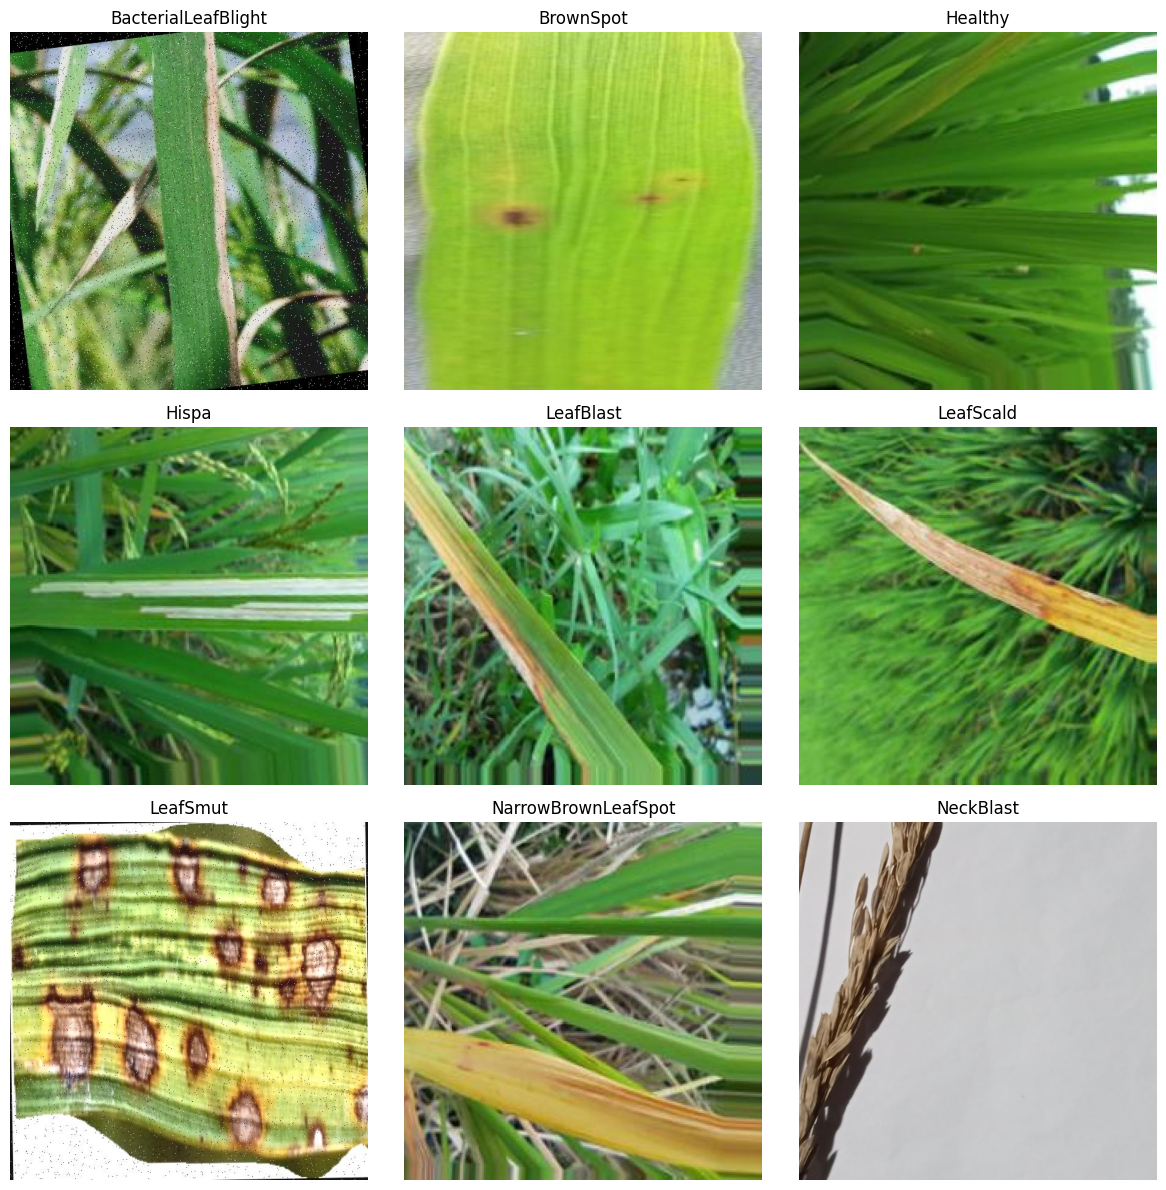

In [5]:
# Class Mapping
class_names = {
    0: "BacterialLeafBlight",
    1: "BrownSpot",
    2: "Healthy",
    3: "Hispa",
    4: "LeafBlast",
    5: "LeafScald",
    6: "LeafSmut",
    7: "NarrowBrownLeafSpot",
    8: "NeckBlast"
}

# Create mapping between class IDs and image paths
class_image_map = defaultdict(list)

labels_dir = DATASET_DIR / "labels" / "train"

for label_file in labels_dir.glob("*.txt"):

    with open(label_file, "r") as f:
        lines = f.readlines()

    if not lines:
        continue

    # Take first class in annotation file
    class_id = int(lines[0].split()[0])

    for ext in [".jpg", ".jpeg", ".png"]:
        image_path = train_images_dir / f"{label_file.stem}{ext}"

        if image_path.exists():
            class_image_map[class_id].append(image_path)
            break

# Display random samples
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, (class_id, class_name) in enumerate(class_names.items()):

    if class_image_map[class_id]:

        image_path = random.choice(class_image_map[class_id])

        img = Image.open(image_path)

        ax = axes[idx // 3, idx % 3]
        ax.imshow(img)
        ax.set_title(class_name)
        ax.axis("off")

plt.tight_layout()
plt.show()

#### Save Visual Image/Label Sample Pairs

Randomly select 5 image/label pairs for each class and save them to the collection output folder.
These saved samples can be used in the dashboard and for manual review of the dataset labels.

In [3]:
# Build sample pools for each class
sample_pairs = {}
label_dirs = [DATASET_DIR / "labels/train", DATASET_DIR / "labels/val"]
image_dirs = [DATASET_DIR / "images/train", DATASET_DIR / "images/val"]

for label_dir in label_dirs:
    for label_path in label_dir.glob("*.txt"):
        if label_path.stat().st_size == 0:
            continue
        with open(label_path, "r", encoding="utf-8") as f:
            first_line = f.readline().strip()
        if not first_line:
            continue
        class_id = int(first_line.split()[0])
        image_name = label_path.stem

        image_path = None
        for image_dir in image_dirs:
            for ext in [".jpg", ".jpeg", ".png"]:
                candidate = image_dir / f"{image_name}{ext}"
                if candidate.exists():
                    image_path = candidate
                    break
            if image_path is not None:
                break

        if image_path is None:
            continue

        sample_pairs.setdefault(class_id, []).append((label_path, image_path))

random.seed(42)
saved_sample_counts = {}

for class_id, items in sample_pairs.items():
    chosen = random.sample(items, min(5, len(items)))
    saved_sample_counts[class_id] = len(chosen)
    for label_path, image_path in chosen:
        copy2(image_path, VISUAL_SAMPLE_IMAGES_DIR / image_path.name)
        copy2(label_path, VISUAL_SAMPLE_LABELS_DIR / label_path.name)

print("Saved visual sample pairs for each class:")
print(saved_sample_counts)


Saved visual sample pairs for each class:
{6: 5, 0: 5, 1: 5, 2: 5, 4: 5, 5: 5, 3: 5, 7: 5, 8: 5}


### 6. Analyze Class Distribution

Analyze the distribution of disease categories across the dataset to identify potential class imbalance and evaluate its possible impact on model performance.

Create helper function

In [6]:
def count_images_per_class(labels_dir, images_dir):
    class_counts = Counter()

    for label_file in labels_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            lines = f.readlines()

        if not lines:
            continue

        # Use first detected class
        class_id = int(lines[0].split()[0])

        # Check image exists
        image_exists = False

        for ext in [".jpg", ".jpeg", ".png"]:
            image_path = images_dir / f"{label_file.stem}{ext}"

            if image_path.exists():
                image_exists = True
                break

        if image_exists:
            class_counts[class_id] += 1

    return class_counts

Count train and validation images

In [7]:
train_class_counts = count_images_per_class(
    DATASET_DIR / "labels/train",
    DATASET_DIR / "images/train"
)

val_class_counts = count_images_per_class(
    DATASET_DIR / "labels/val",
    DATASET_DIR / "images/val"
)

print("Training distribution:")
print(train_class_counts)

print("\nValidation distribution:")
print(val_class_counts)

Training distribution:
Counter({6: 1600, 0: 1600, 1: 1600, 5: 365, 8: 363, 4: 360, 7: 355, 2: 347, 3: 345})

Validation distribution:
Counter({6: 400, 0: 400, 1: 400, 5: 91, 8: 90, 4: 89, 7: 88, 3: 86, 2: 86})


Create Analysis DataFrame

In [8]:
df_distribution = pd.DataFrame({
    "Class": [class_names[i] for i in class_names.keys()],
    "Train Images": [train_class_counts.get(i, 0) for i in class_names.keys()],
    "Validation Images": [val_class_counts.get(i, 0) for i in class_names.keys()],
})

df_distribution["Total Images"] = (
    df_distribution["Train Images"] + df_distribution["Validation Images"]
)

df_distribution

,Class,Train Images,Validation Images,Total Images
0,BacterialLeafBlight,1600,400,2000
1,BrownSpot,1600,400,2000
2,Healthy,347,86,433
3,Hispa,345,86,431
4,LeafBlast,360,89,449
5,LeafScald,365,91,456
6,LeafSmut,1600,400,2000
7,NarrowBrownLeafSpot,355,88,443
8,NeckBlast,363,90,453


Visualize Class Distribution

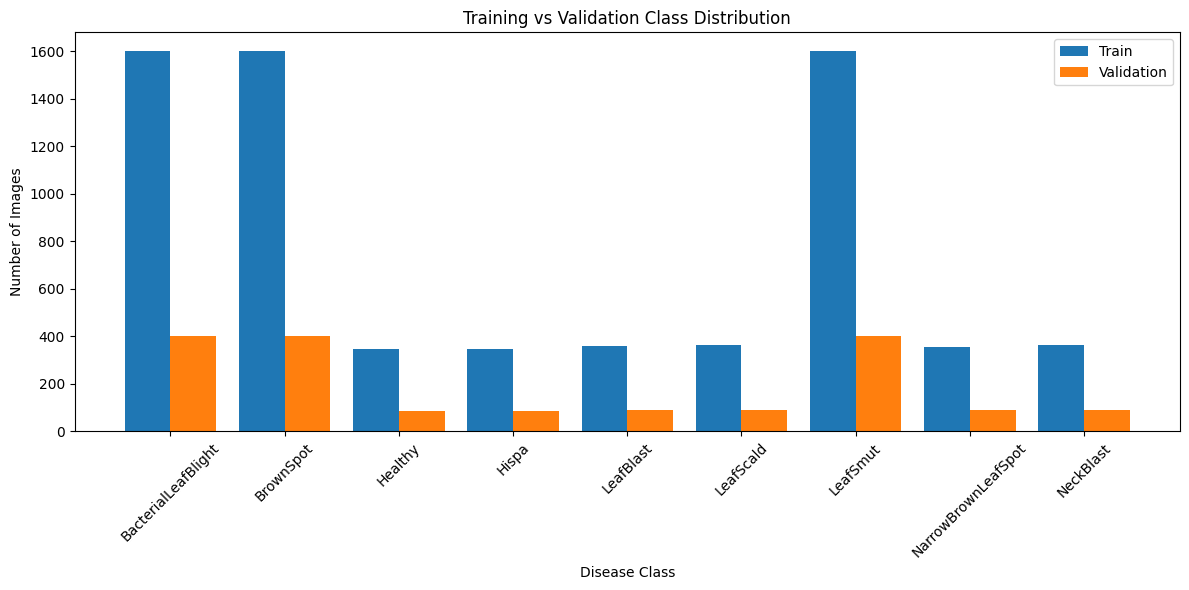

In [9]:
x = np.arange(len(df_distribution["Class"]))
width = 0.4

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    df_distribution["Train Images"],
    width,
    label="Train"
)

plt.bar(
    x + width / 2,
    df_distribution["Validation Images"],
    width,
    label="Validation"
)

plt.xticks(x, df_distribution["Class"], rotation=45)

plt.ylabel("Number of Images")
plt.xlabel("Disease Class")

plt.title("Training vs Validation Class Distribution")

plt.legend()

plt.tight_layout()
plt.show()

#### Observations

- The dataset shows noticeable class imbalance across disease categories.
- Some classes contain significantly more samples than others.
- Imbalanced datasets may negatively affect model performance, particularly for minority classes.
- Additional preprocessing or balancing techniques may be considered during model development.

### 7. Analyze Image Characteristics

Analyze image properties such as dimensions, aspect ratios, and color characteristics to better understand dataset consistency and identify potential preprocessing requirements.

Collect Image Metadata

In [10]:
image_metadata = []

# Combine train and validation images
all_images = train_images + val_images

for image_path in all_images:
    try:
        with Image.open(image_path) as img:
            width, height = img.size

            image_metadata.append({
                "image": image_path.name,
                "width": width,
                "height": height,
                "aspect_ratio": round(width / height, 2)
            })

    except Exception as e:
        print(f"Error loading {image_path.name}: {e}")

df_image_metadata = pd.DataFrame(image_metadata)

df_image_metadata.head()

,image,width,height,aspect_ratio
0,r6k_test_Blast_1040_jpg.rf.1b4df5035f843e4ece4...,587,587,1.0
1,r6k_test_Blast_1042_jpg.rf.bd326b9f9af9c1a2ae7...,587,587,1.0
2,r6k_test_Blast_1048_jpg.rf.6e35f9f409e6f90df0d...,587,587,1.0
3,r6k_test_Blast_1050_jpg.rf.829589c7deda60d55ed...,587,587,1.0
4,r6k_test_Blast_1060_jpg.rf.b86783516b1eb84925f...,587,587,1.0


Image Resolution Analysis

In [11]:
# Create resolution column
df_image_metadata["resolution"] = (
    df_image_metadata["width"].astype(str) + "x" + df_image_metadata["height"].astype(str)
)

# Count resolutions
resolution_counts = (
    df_image_metadata["resolution"]
    .value_counts()
    .reset_index()
)

resolution_counts.columns = ["Resolution", "Count"]

resolution_counts

,Resolution,Count
0,587x587,5292
1,640x640,3373


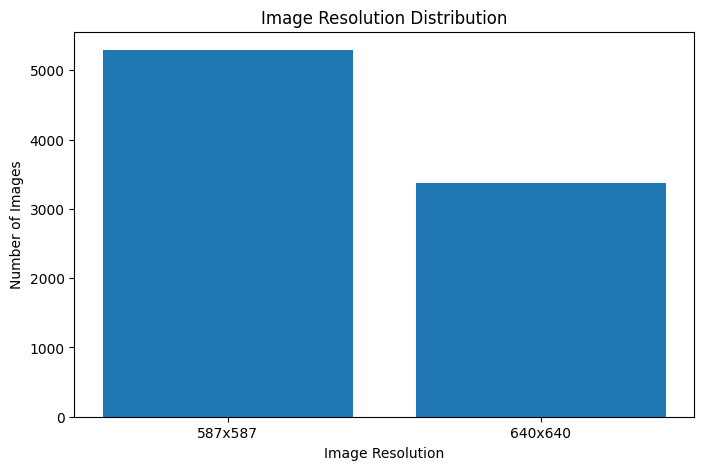

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    resolution_counts["Resolution"],
    resolution_counts["Count"]
)

plt.xlabel("Image Resolution")
plt.ylabel("Number of Images")
plt.title("Image Resolution Distribution")

plt.show()

Color Distribution Analysis

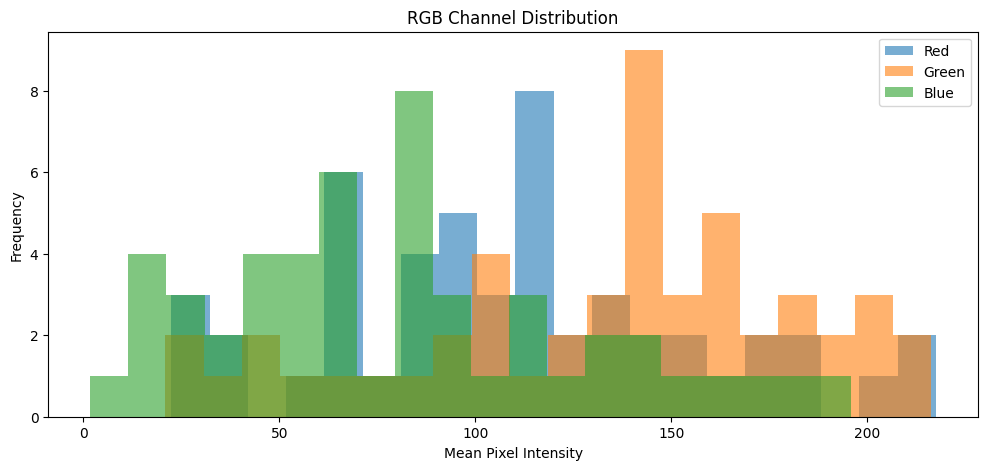

In [13]:
sample_images = random.sample(all_images, min(50, len(all_images)))

mean_red = []
mean_green = []
mean_blue = []

for image_path in sample_images:

    img = Image.open(image_path).convert("RGB")

    img_array = np.array(img)

    mean_red.append(img_array[:, :, 0].mean())
    mean_green.append(img_array[:, :, 1].mean())
    mean_blue.append(img_array[:, :, 2].mean())

plt.figure(figsize=(12, 5))

plt.hist(mean_red, bins=20, alpha=0.6, label="Red")
plt.hist(mean_green, bins=20, alpha=0.6, label="Green")
plt.hist(mean_blue, bins=20, alpha=0.6, label="Blue")

plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Frequency")
plt.title("RGB Channel Distribution")

plt.legend()

plt.show()

Brightness and Contrast Analysis

In [14]:
brightness_values = []
contrast_values = []

sample_images = random.sample(
    all_images,
    min(100, len(all_images))
)

for image_path in sample_images:

    img = Image.open(image_path).convert("L")

    img_array = np.array(img)

    # Mean brightness
    brightness_values.append(img_array.mean())

    # Contrast approximation using standard deviation
    contrast_values.append(img_array.std())

Brightness Distribution Plot

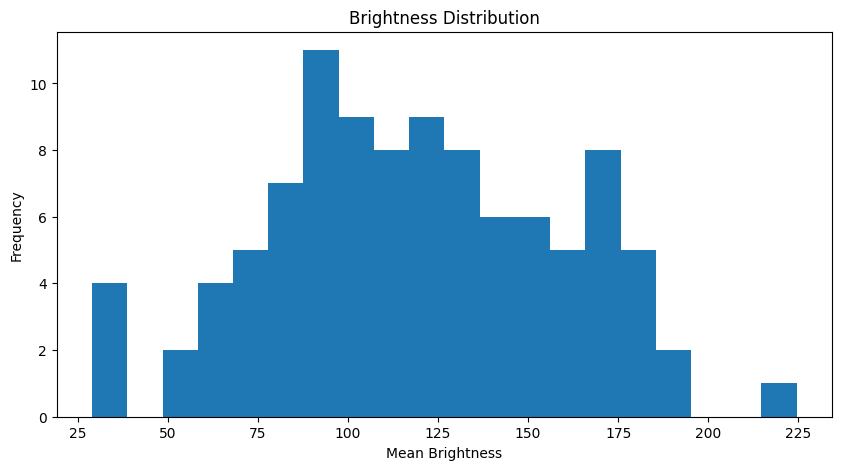

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(brightness_values, bins=20)

plt.xlabel("Mean Brightness")
plt.ylabel("Frequency")
plt.title("Brightness Distribution")

plt.show()

Contrast Distribution Plot

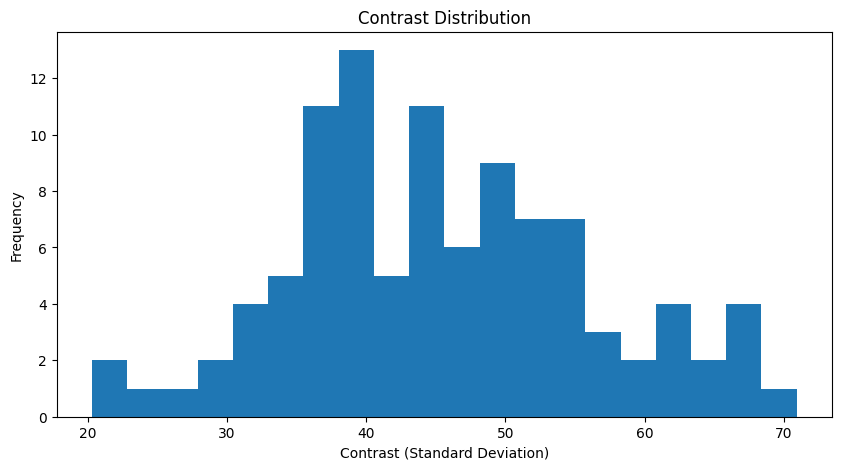

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(contrast_values, bins=20)

plt.xlabel("Contrast (Standard Deviation)")
plt.ylabel("Frequency")
plt.title("Contrast Distribution")

plt.show()

#### Observations

- The dataset contains only two image resolutions: `587x587` and `640x640`.
- All images use a square aspect ratio (`1:1`), indicating strong dataset consistency.
- The standardized image dimensions simplify preprocessing and reduce the need for extensive resizing or cropping operations.
- Consistent image formatting is expected to support stable model training performance.
- RGB distribution analysis indicates noticeable variation in color intensity, which may assist disease classification.
- Differences in color and texture between classes may provide useful signals for machine learning models.
- Brightness and contrast distributions show moderate variation across images, suggesting that normalization and augmentation techniques may improve model robustness under different lighting conditions.

### 8. Compare Disease Patterns

Compare visual characteristics across rice leaf disease categories to identify similarities, differences, and potential classification challenges.

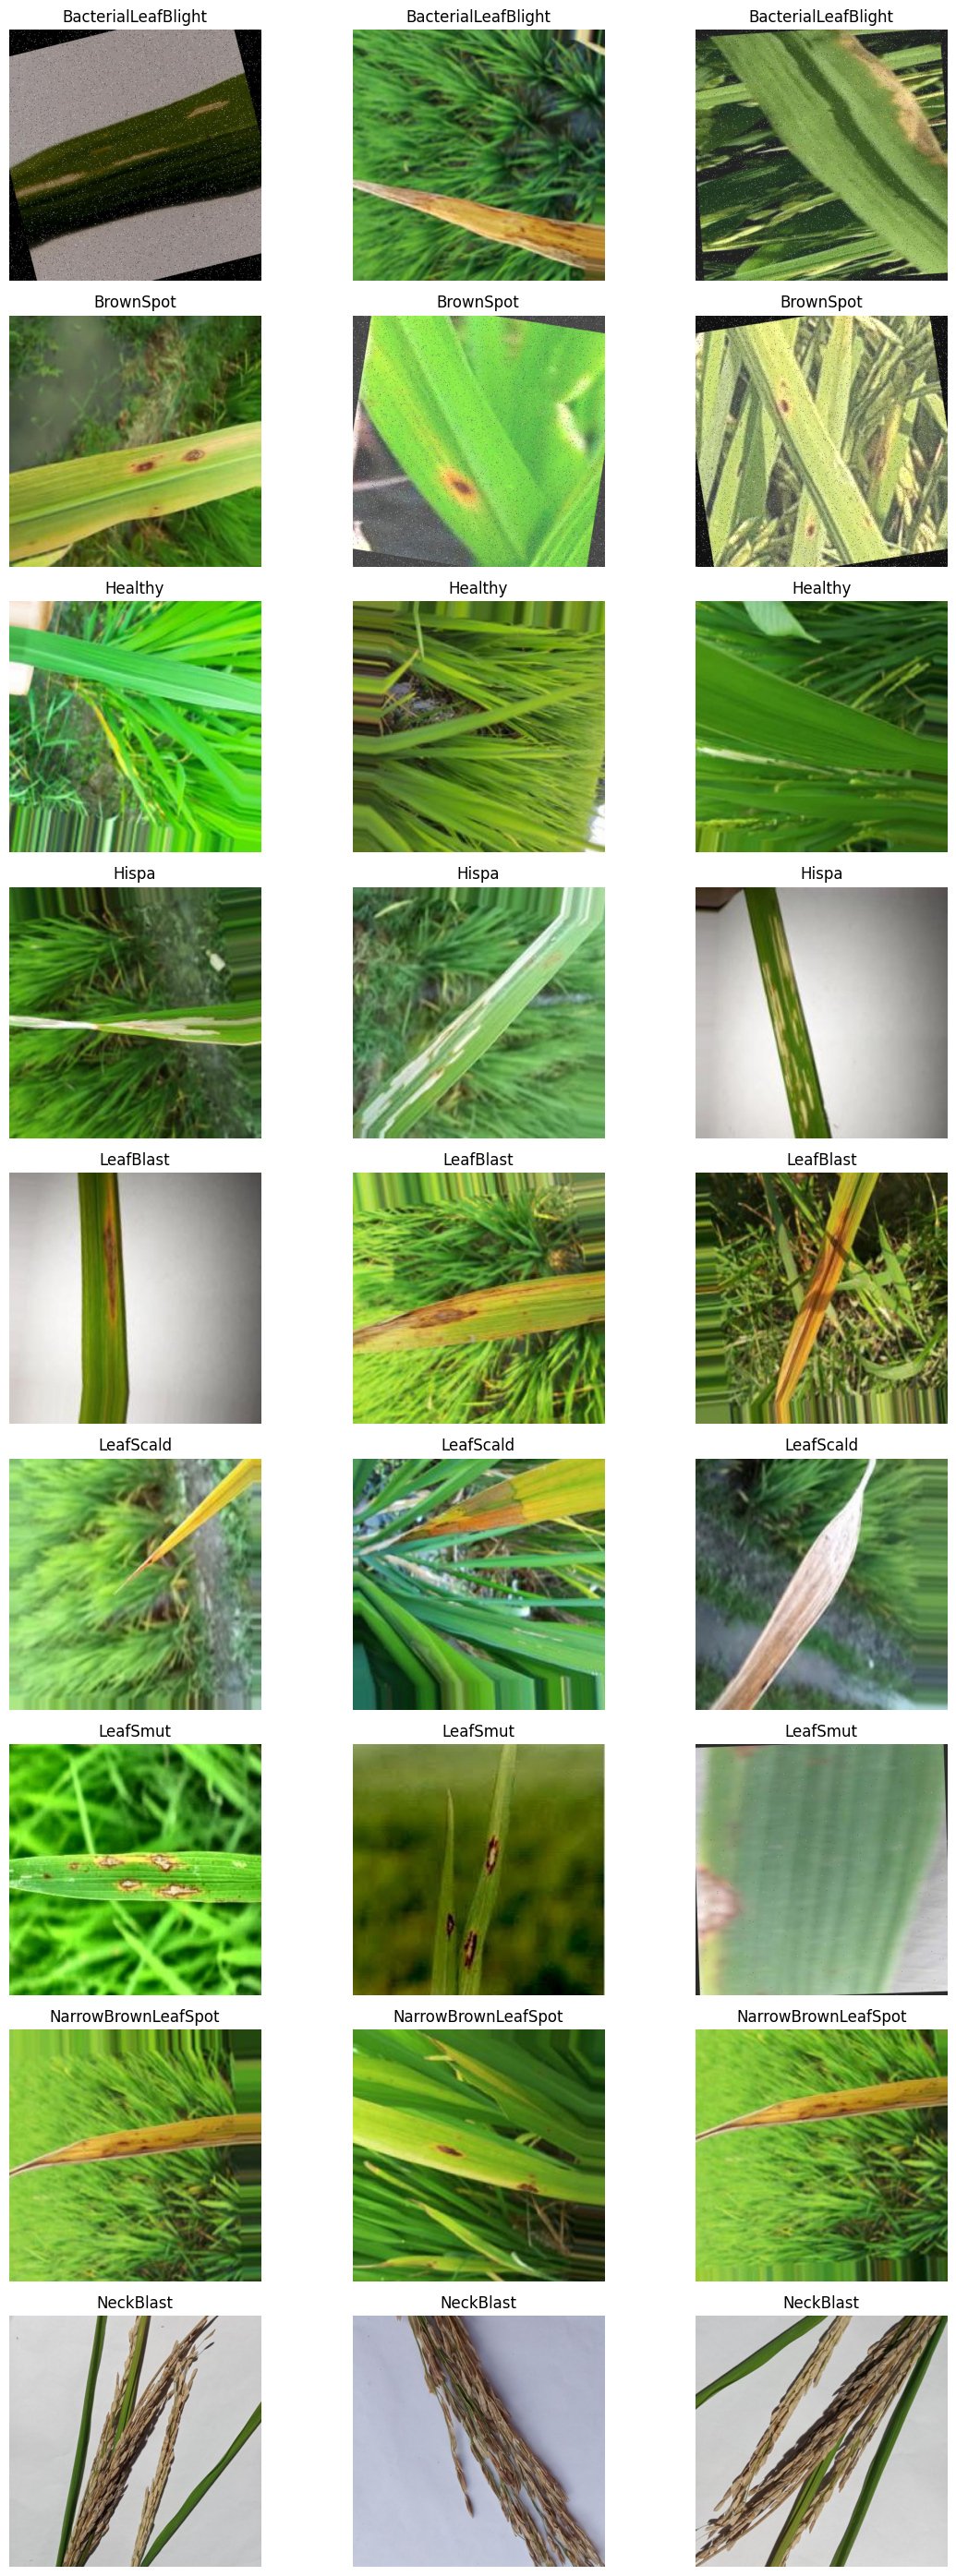

In [17]:
samples_per_class = 3

fig, axes = plt.subplots(
    len(class_names),
    samples_per_class,
    figsize=(12, 28)
)

for row_idx, (class_id, class_name) in enumerate(class_names.items()):

    available_images = class_image_map[class_id]

    if len(available_images) < samples_per_class:
        selected_images = available_images
    else:
        selected_images = random.sample(
            available_images,
            samples_per_class
        )

    for col_idx in range(samples_per_class):

        ax = axes[row_idx, col_idx]

        if col_idx < len(selected_images):

            img = Image.open(selected_images[col_idx])

            ax.imshow(img)
            ax.set_title(class_name)

        ax.axis("off")

plt.tight_layout()
plt.show()

### Observations

- Several disease categories display distinct visual patterns, including discoloration, spotting, and texture changes.
- Some diseases appear visually similar, which may increase classification difficulty for the model.
- Healthy leaves generally show more uniform color and texture characteristics compared to diseased samples.
- Variability within certain disease categories suggests that robust model generalization will be important during training.

### 9. Summarize Findings

This section summarizes the key insights identified during exploratory data analysis and connects them to the project business requirements and hypotheses.

#### Key Findings

- The dataset structure is consistent and suitable for image classification workflows.
- Images are standardized into two square resolutions (`587x587` and `640x640`), reducing preprocessing complexity.
- The dataset contains noticeable class imbalance, with several disease categories significantly more represented than others.
- Visual analysis shows clear differences between healthy and diseased rice leaves in terms of color, spotting patterns, and texture.
- Some disease categories share similar visual characteristics, which may create classification challenges for the model.
- RGB, brightness, and contrast analysis indicate moderate variation in image appearance and lighting conditions.
- The exploratory analysis supports the hypothesis that rice leaf diseases can be differentiated using image classification techniques.

#### Relation to Business Requirements

The findings from this notebook support:

- **Business Requirement 1:**
  Visual differences between healthy and diseased rice leaves were identified and explored through image analysis and visualization.

- **Business Requirement 2:**
  The dataset appears suitable for training a machine learning model capable of classifying rice leaf diseases from images.

### 10. Save EDA Outputs

Save generated plots and analysis outputs for later use in the Streamlit dashboard and project reporting.

In [18]:
# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save class distribution table
df_distribution.to_csv(
    OUTPUT_DIR / "class_distribution.csv",
    index=False
)

# Save image metadata
df_image_metadata.to_csv(
    OUTPUT_DIR / "image_metadata.csv",
    index=False
)

print("EDA outputs saved successfully.")

EDA outputs saved successfully.


## Conclusions

The exploratory data analysis provided valuable insight into the structure, quality, and visual characteristics of the rice leaf disease dataset. The results suggest that the dataset is suitable for image classification tasks and contains meaningful visual patterns that may support successful disease prediction using machine learning techniques.

The findings from this notebook will guide preprocessing decisions and support model development in the following stages of the project.